In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np
from matplotlib import pyplot as plt
import sys, os
sys.path.append("../../src/")

import scipy.stats as stats
from tqdm import tqdm
from baseline_network import BaselineNetwork

In [4]:
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = 'Arial'

In [5]:
save_loc_general = "../../results/05-22 - all-to-all/3A. all plastic - co-tuned inh/"
if not os.path.exists(save_loc_general):
    os.makedirs(save_loc_general)

/Users/divyansh/Library/CloudStorage/GoogleDrive-divyanshg1207@gmail.com/My Drive/Course Stuff/PhD/Projects | PhD/sensory drift/drift_model_2026/scripts/05-22 - all_to_all/../../src/baseline_network.py:691: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
100%|██████████| 840/840 [23:49<00:00,  1.70s/it]  
/Users/divyansh/Library/CloudStorage/GoogleDrive-divyanshg1207@gmail.com/My Drive/Course Stuff/PhD/Projects | PhD/sensory drift/drift_model_2026/scripts/05-22 - all_to_all/../../src/baseline_network.py:713: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/Users/divyansh/Library/CloudStorage/GoogleDrive-divyanshg1207@gmail.com/My Drive/Course Stuff/PhD/Projects | PhD/sensory drift/drift_model_2026/scripts/05-22 - all_to_all/../../src/baseline_network.py:751: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
days: 100%|██████████| 28/28 [44:30<00:00, 95.39s/it]   
/Users/di

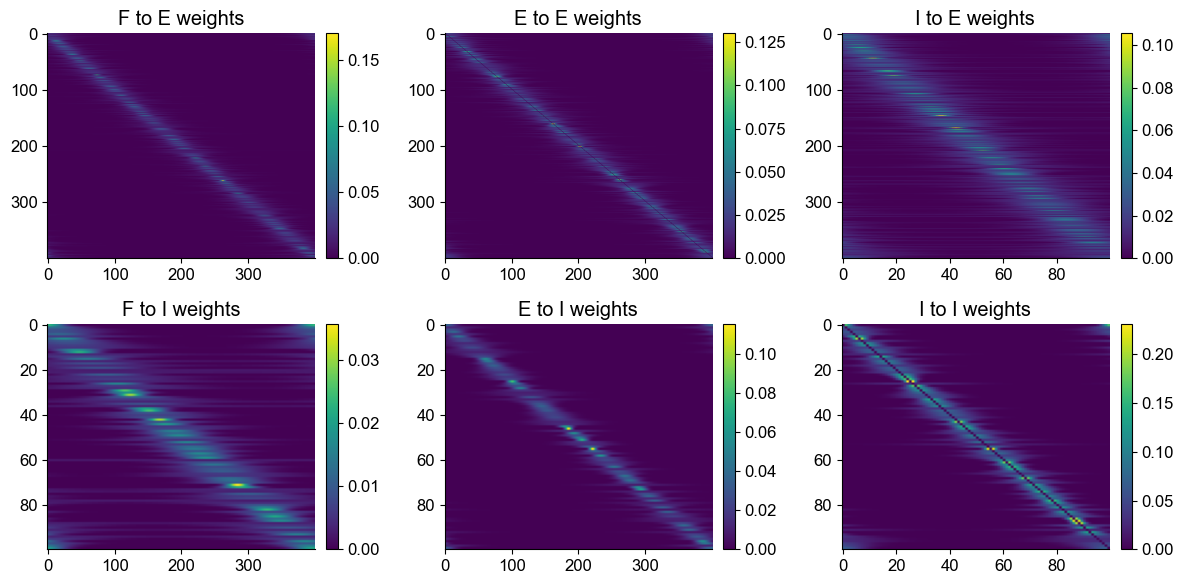

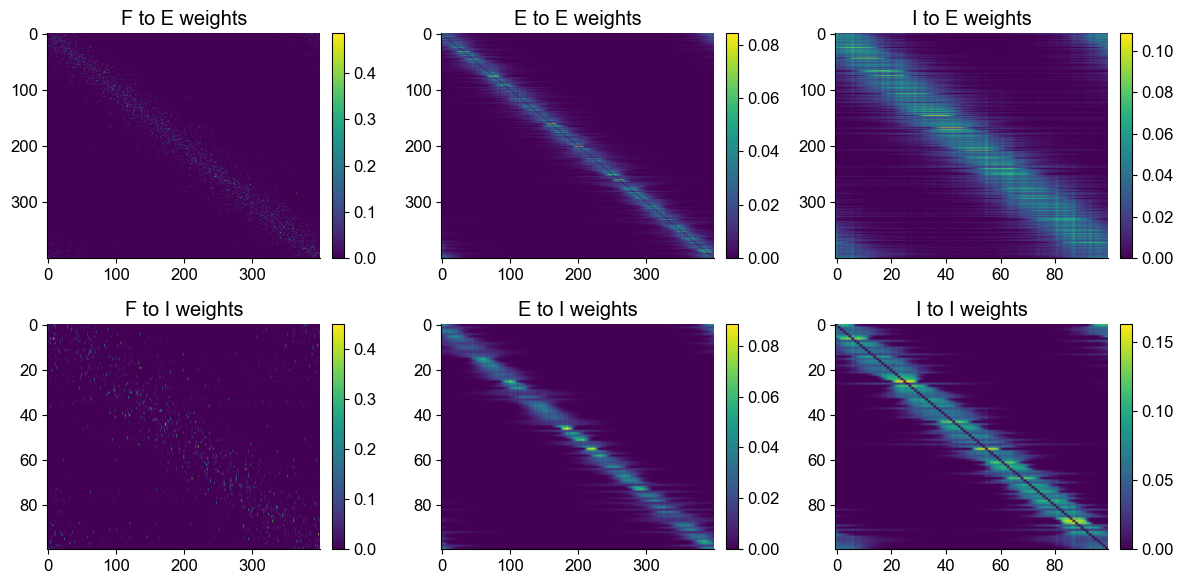

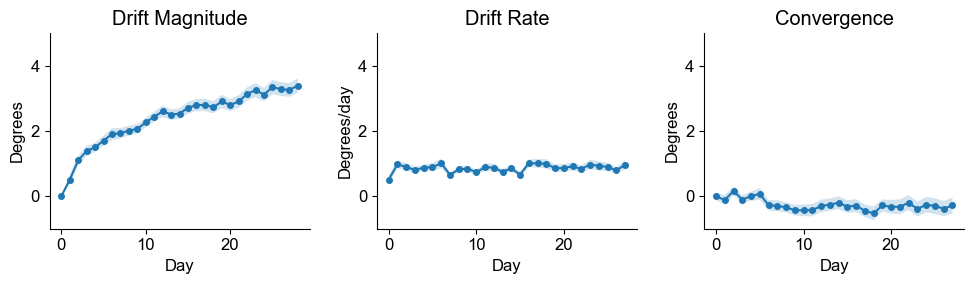

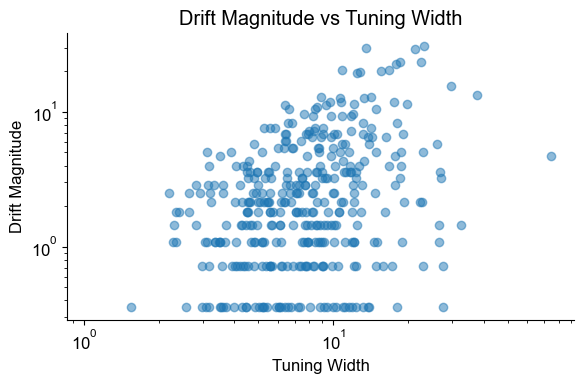

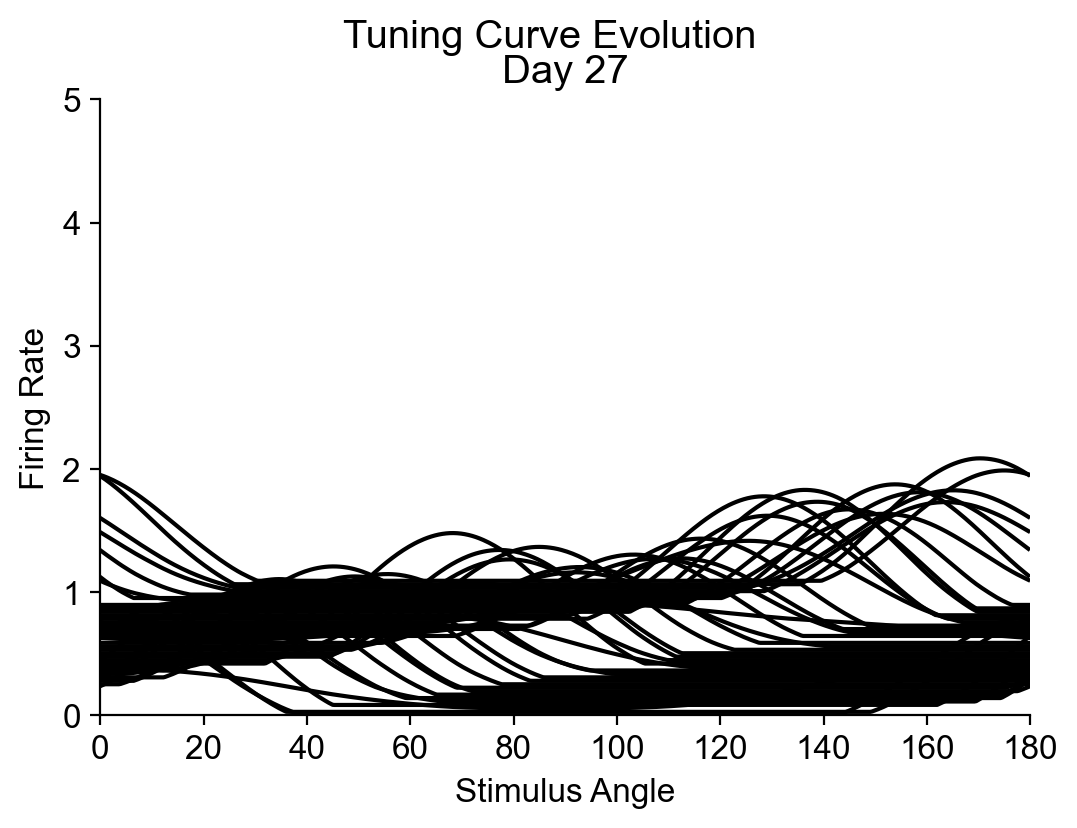

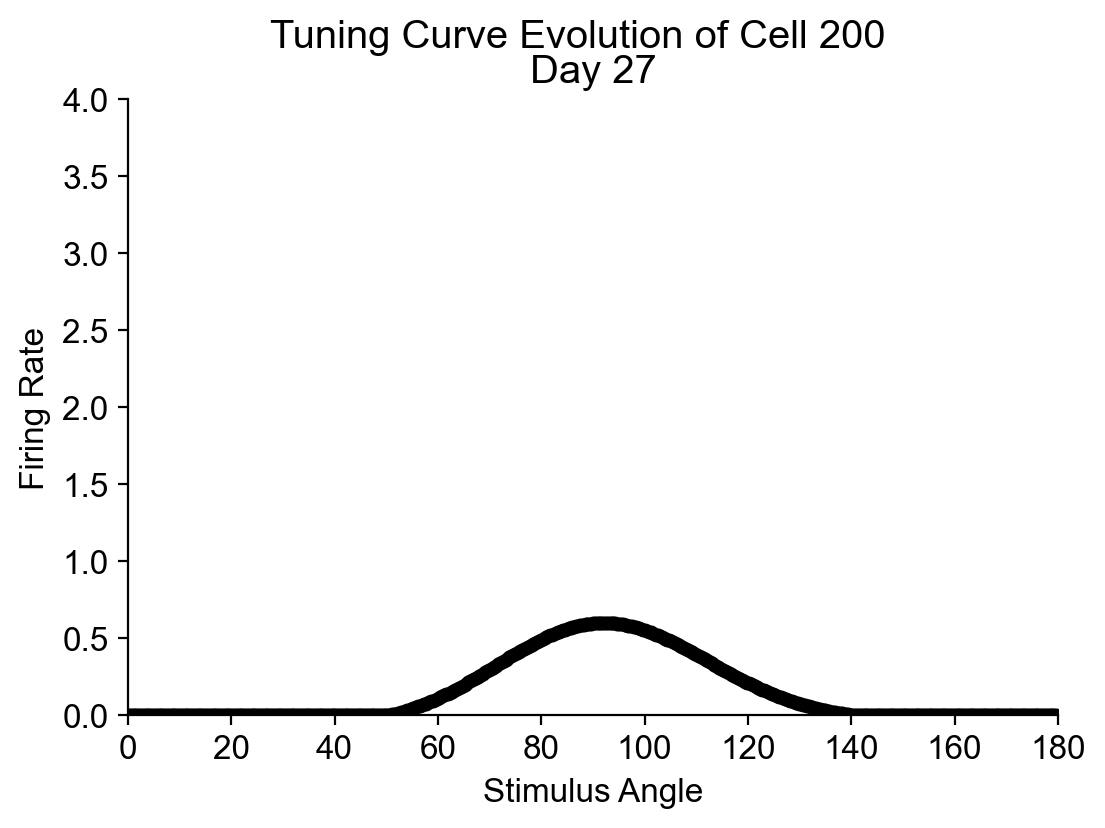

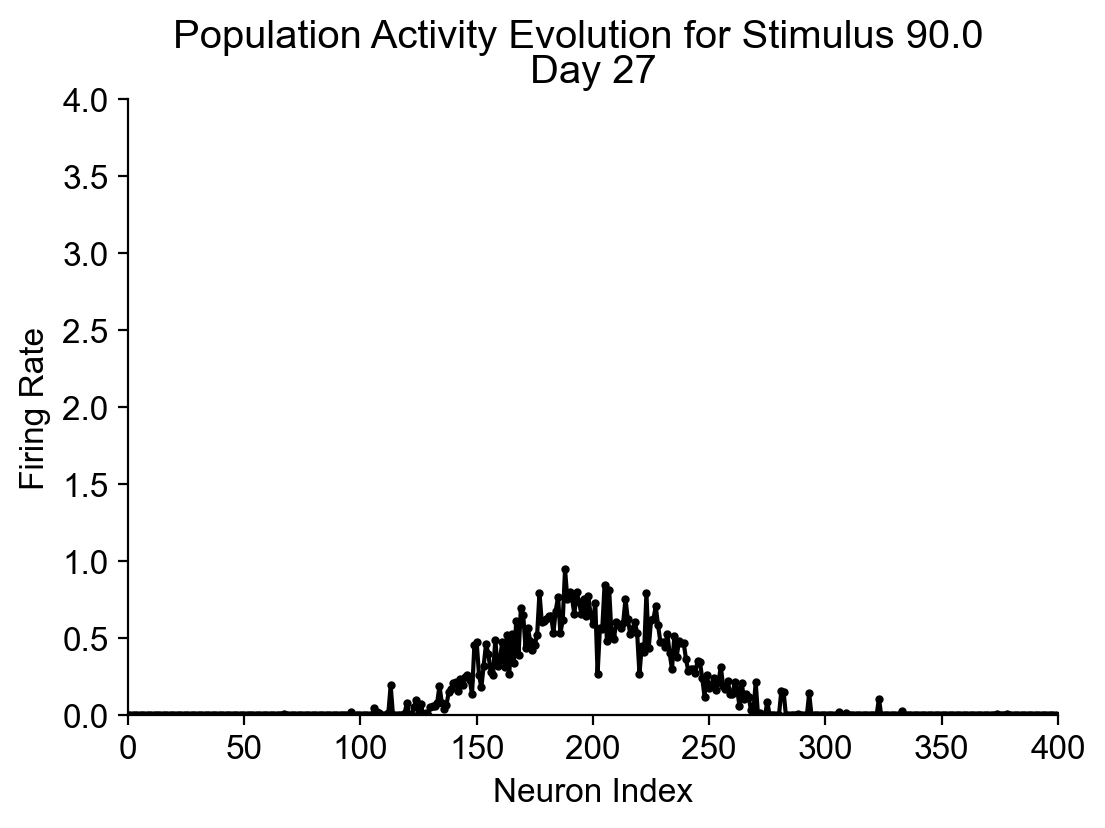

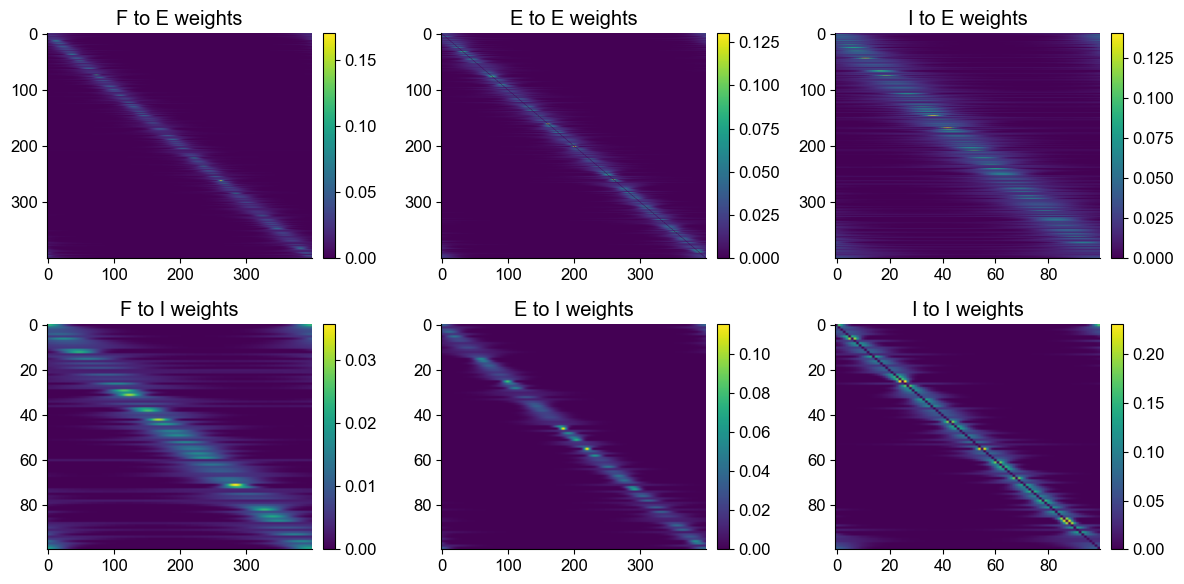

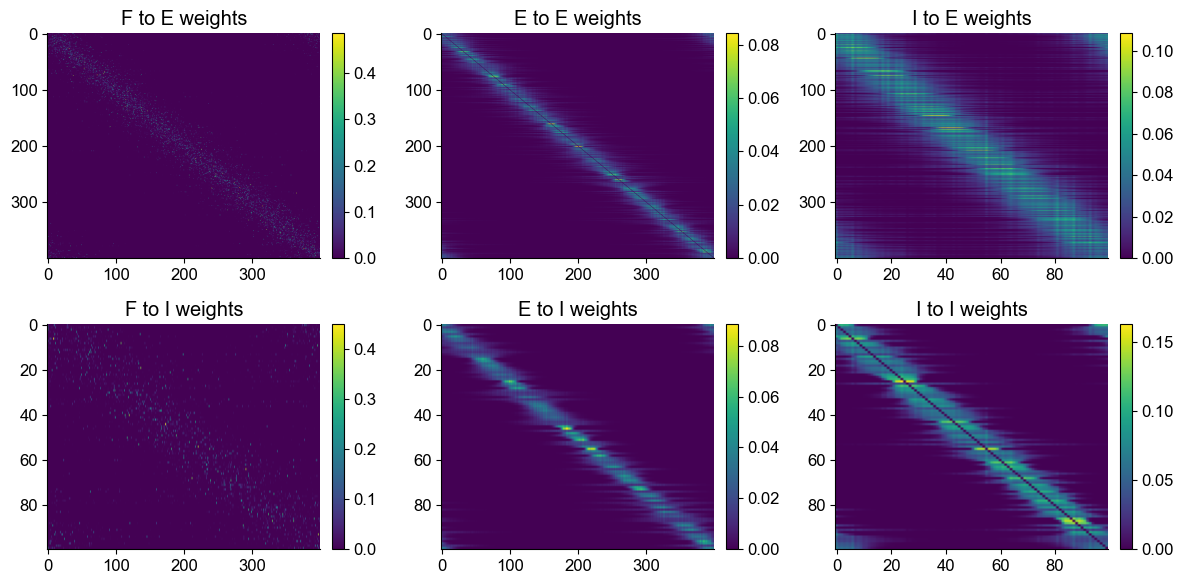

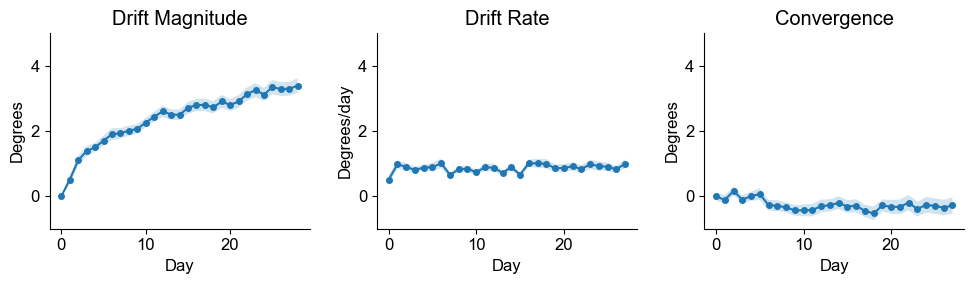

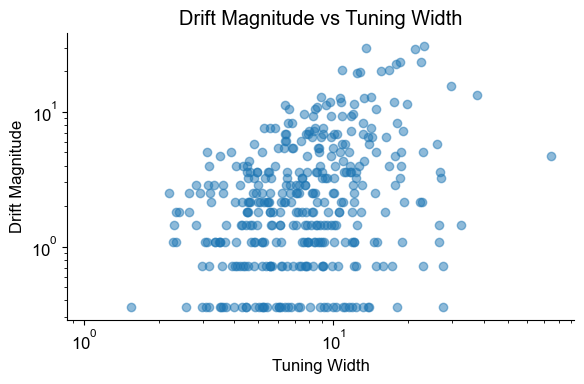

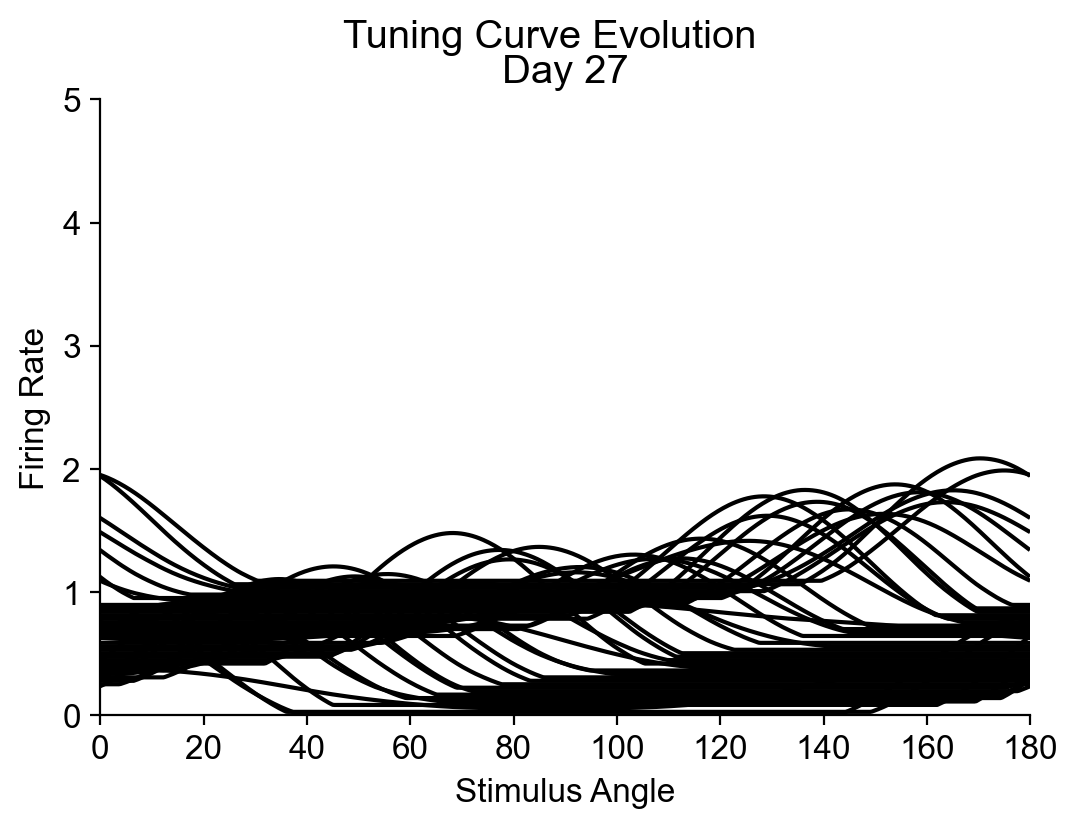

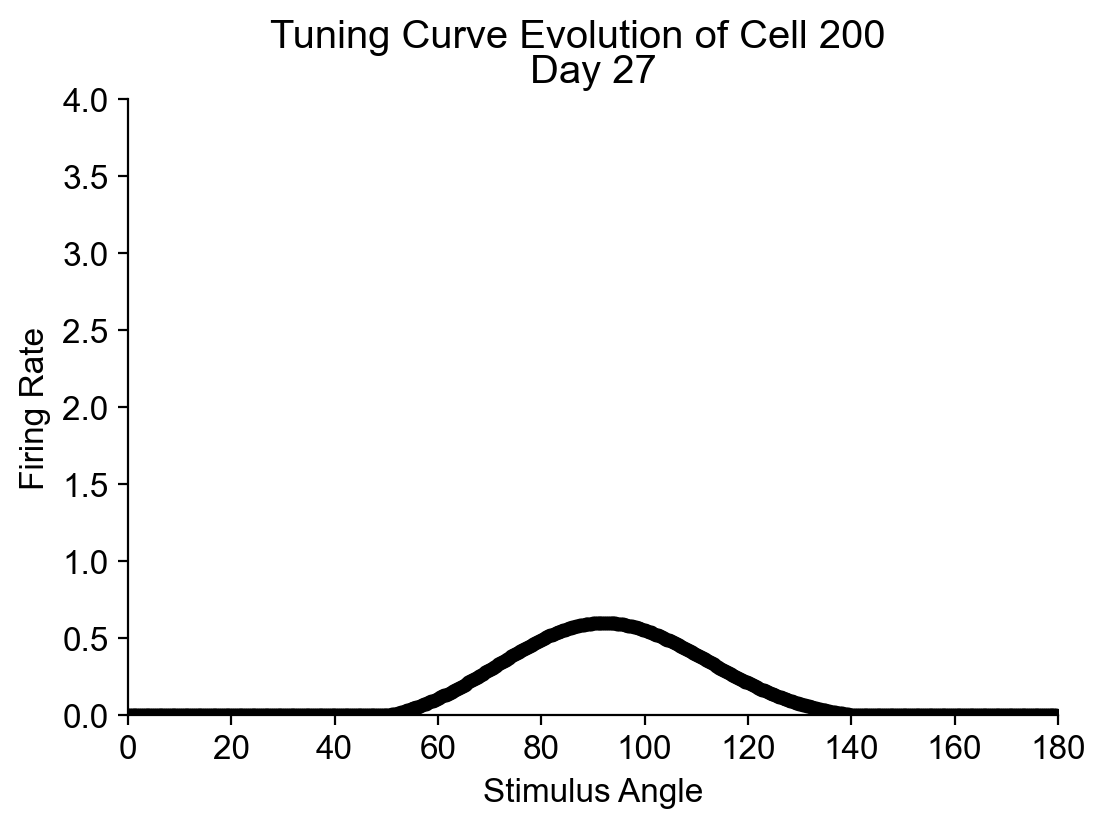

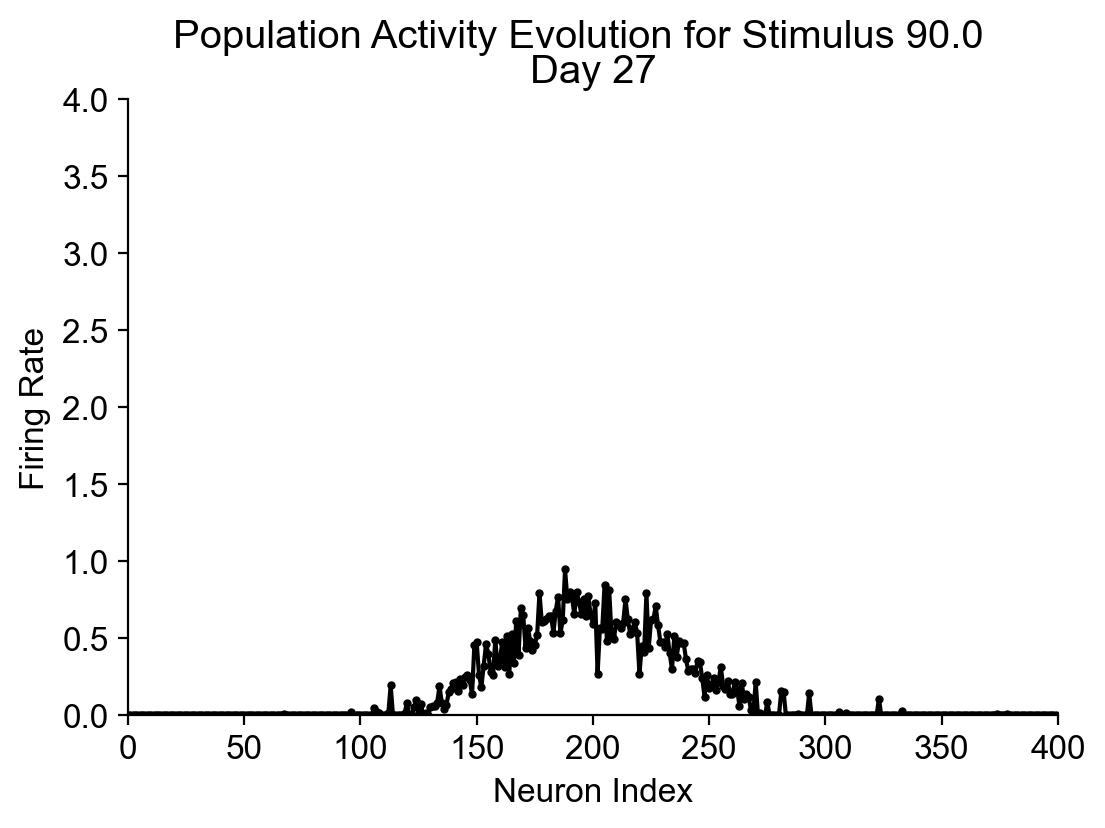

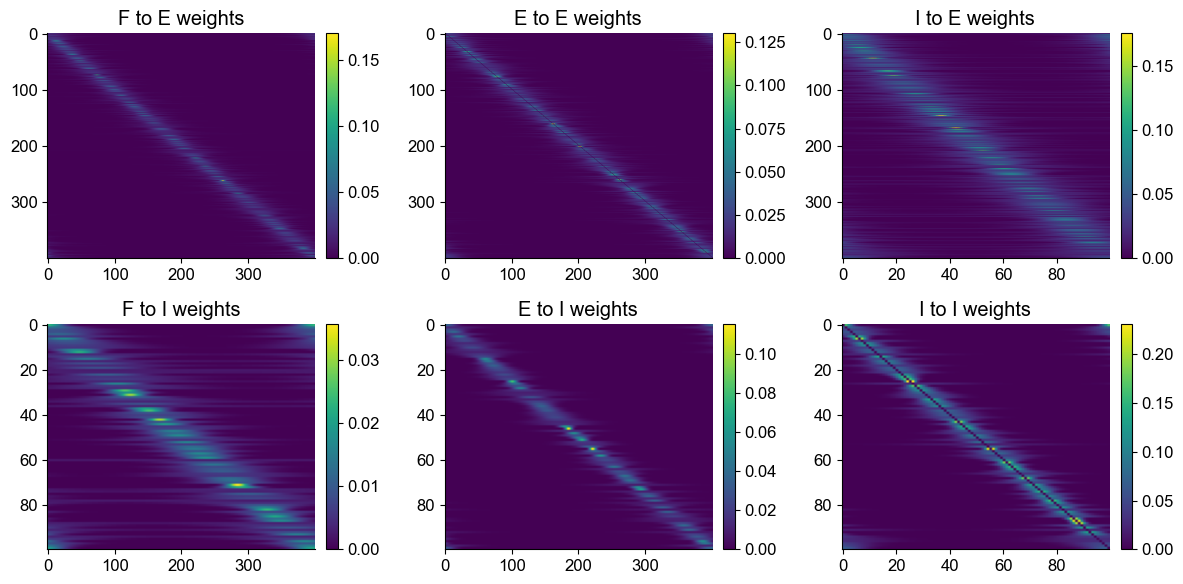

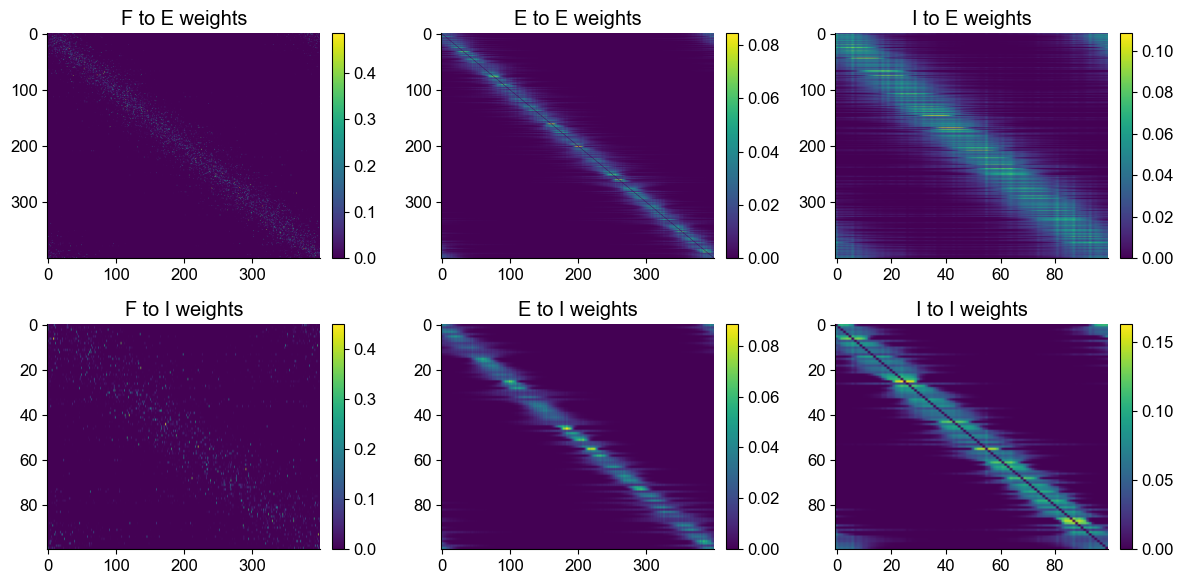

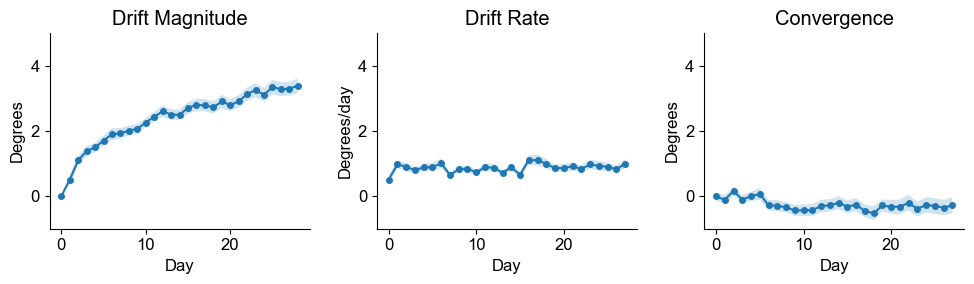

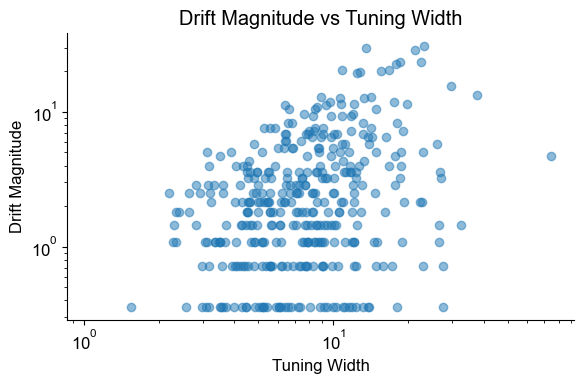

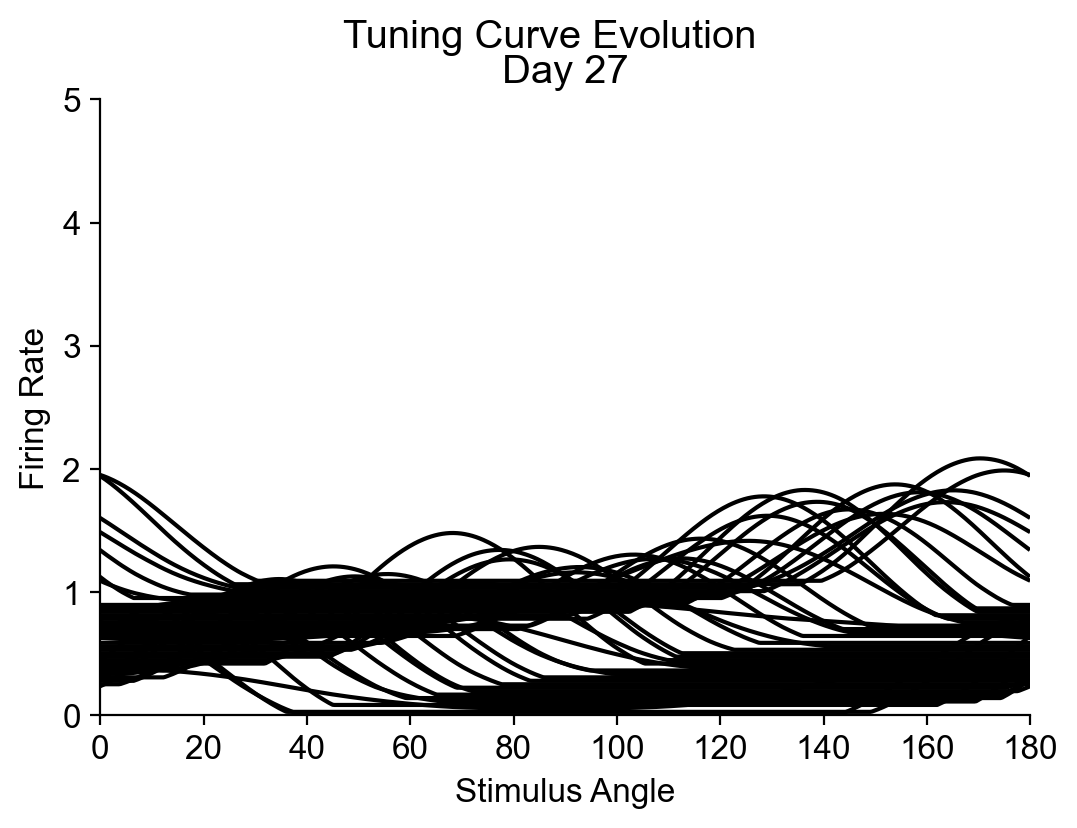

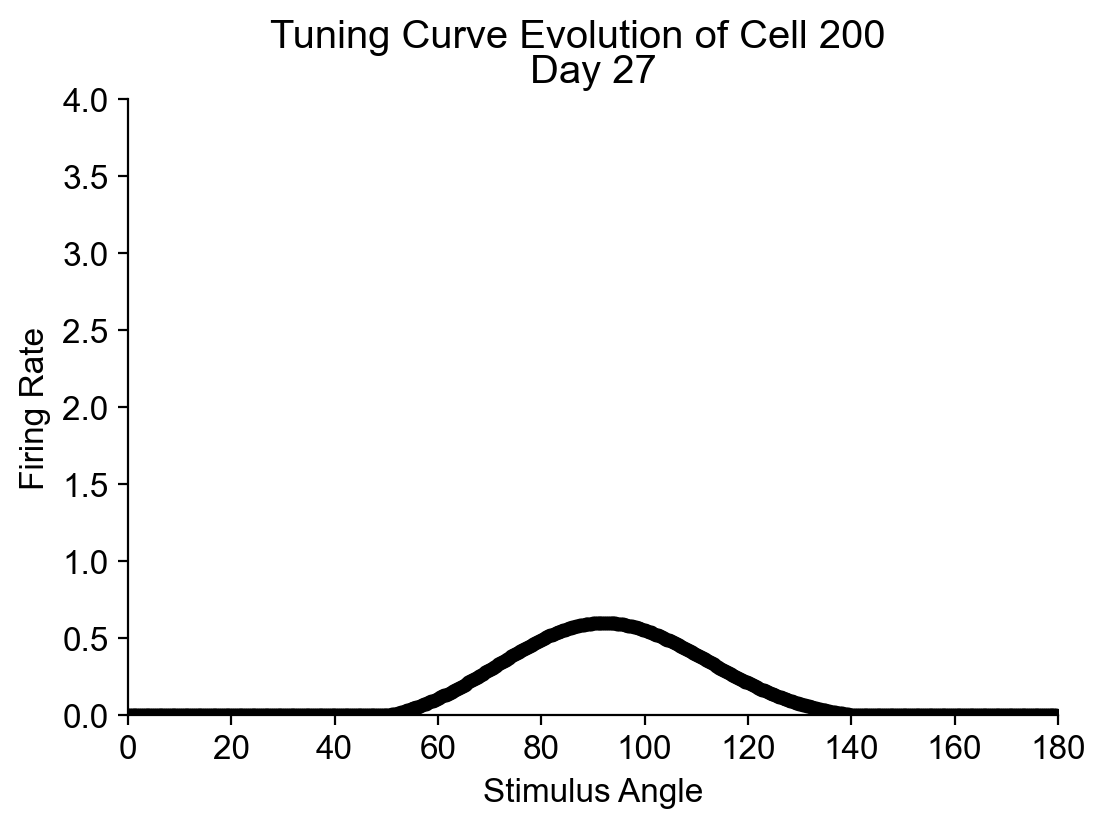

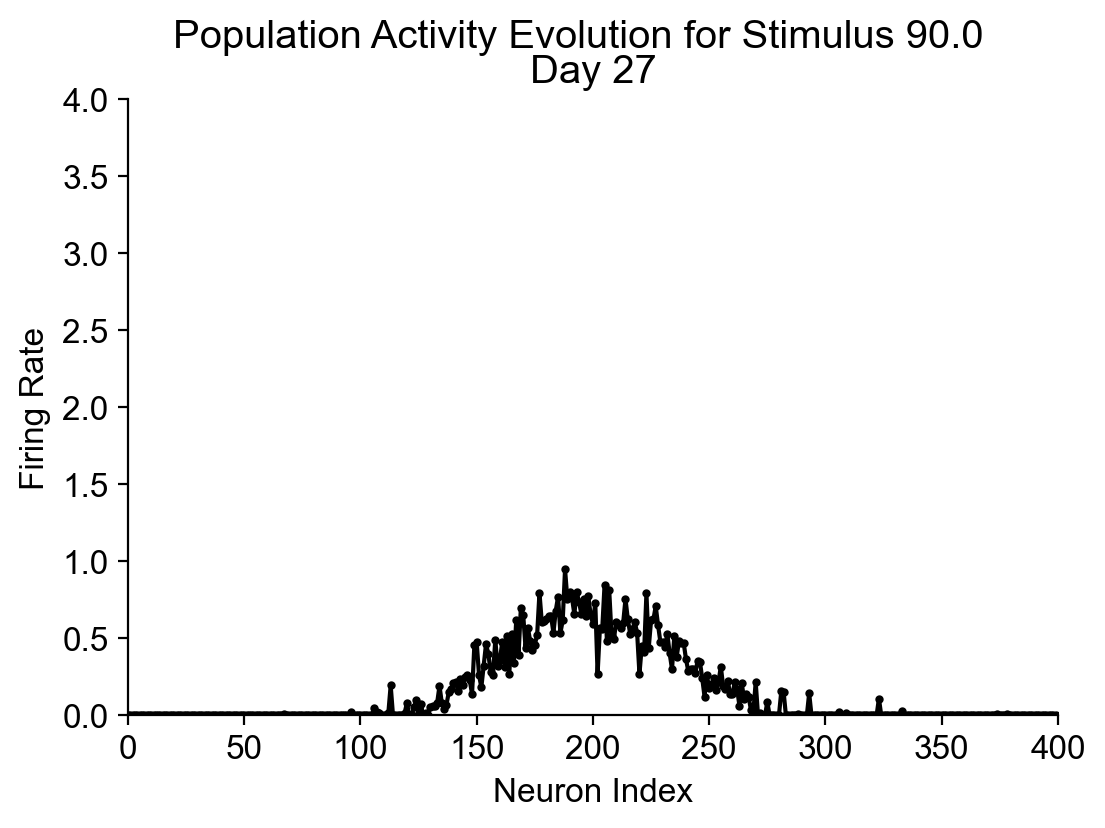

In [6]:
net_inh_1 = BaselineNetwork(inh_type="co-tuned", E_to_E="on", E_to_I="on", I_to_I="on",
                      plasticity_E_to_E="on", plasticity_E_to_I="on", plasticity_I_to_E="on", plasticity_I_to_I="on",
                      plasticity_F_to_I="on",
                      norm=True, set_seed=True, seed=42, 
                      inh_scale=0.6, 
                      save_location=save_loc_general + "inh_scale_0.6/")
net_inh_1.run_analysis(save_results=True)

net_inh_2 = BaselineNetwork(inh_type="co-tuned", E_to_E="on", E_to_I="on", I_to_I="on",
                      plasticity_E_to_E="on", plasticity_E_to_I="on", plasticity_I_to_E="on", plasticity_I_to_I="on",
                      plasticity_F_to_I="on",
                      norm=True, set_seed=True, seed=42, 
                      inh_scale=0.8, 
                      save_location=save_loc_general + "inh_scale_0.8/")
net_inh_2.run_analysis(save_results=True)

net_inh_3 = BaselineNetwork(inh_type="co-tuned", E_to_E="on", E_to_I="on", I_to_I="on",
                      plasticity_E_to_E="on", plasticity_E_to_I="on", plasticity_I_to_E="on", plasticity_I_to_I="on",
                      plasticity_F_to_I="on",
                      norm=True, set_seed=True, seed=42, 
                      inh_scale=1.0, 
                      save_location=save_loc_general + "inh_scale_1.0/")
net_inh_3.run_analysis(save_results=True)

In [ ]:
net_inh_1 = BaselineNetwork(inh_type="co-tuned", E_to_E="on", E_to_I="on", I_to_I="on",
                      plasticity_E_to_E="on", plasticity_E_to_I="on", plasticity_I_to_E="on", plasticity_I_to_I="on",
                      plasticity_F_to_I="on",
                      norm=True, set_seed=True, seed=42, 
                      inh_scale=0.3)
net_inh_1.run()

net_inh_2 = BaselineNetwork(inh_type="co-tuned", E_to_E="off", E_to_I="off", I_to_I="off",
                      plasticity_E_to_E="off", plasticity_E_to_I="off", plasticity_I_to_E="off", plasticity_I_to_I="off",
                      plasticity_F_to_I="on",
                      norm=True, set_seed=True, seed=42, 
                      inh_scale=0.6)
net_inh_2.run()

net_inh_3 = BaselineNetwork(inh_type="co-tuned", E_to_E="off", E_to_I="off", I_to_I="off",
                      plasticity_E_to_E="off", plasticity_E_to_I="off", plasticity_I_to_E="off", plasticity_I_to_I="off",
                      plasticity_F_to_I="on",
                      norm=True, set_seed=True, seed=42, 
                      inh_scale=0.9)
net_inh_3.run()

In [ ]:
drift_mag_1, drift_rate_1, convergence_1 = net_inh_1.get_drift_metrics()
drift_mag_2, drift_rate_2, convergence_2 = net_inh_2.get_drift_metrics()
drift_mag_3, drift_rate_3, convergence_3 = net_inh_3.get_drift_metrics()

In [ ]:
fig, axs = plt.subplots(1,3, figsize=(12, 3), dpi=200)
axs[0].plot(np.nanmean(drift_mag_1, axis=1), marker='o', label="I scale = 0.3")
axs[0].plot(np.nanmean(drift_mag_2, axis=1), marker='o', label="I scale = 0.6")
axs[0].plot(np.nanmean(drift_mag_3, axis=1), marker='o', label="I scale = 0.9")
axs[0].set_title("Drift magnitude")
axs[0].legend()
axs[0].set_ylim([-1, 6])


axs[1].plot(np.nanmean(drift_rate_1, axis=1), marker='o', label="I scale = 0.3")
axs[1].plot(np.nanmean(drift_rate_2, axis=1), marker='o', label="I scale = 0.6")
axs[1].plot(np.nanmean(drift_rate_3, axis=1), marker='o', label="I scale = 0.9")
axs[1].set_title("Drift rate")
axs[1].legend()
axs[1].set_ylim([-1, 5])

axs[2].plot(np.nanmean(convergence_1, axis=1), marker='o', label="I scale = 0.3")
axs[2].plot(np.nanmean(convergence_2, axis=1), marker='o', label="I scale = 0.6")
axs[2].plot(np.nanmean(convergence_3, axis=1), marker='o', label="I scale = 0.9")
axs[2].set_title("Convergence")
axs[2].legend()
axs[2].set_ylim([-1, 5])
